In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from boruta import BorutaPy
# 데이터 불러오기
file_path = '/Users/kimte/Desktop/노인노쇠코호트/kfacs_imputed_data.csv'
data = pd.read_csv(file_path)

In [2]:
# 필요없는 컬럼 제거
columns_to_remove = ['BL_CHS_version02', 'Polypharmacy', 'comorbidities_No_13', 'No']
data = data.drop(columns=columns_to_remove)

# 범주형 변수 인코딩
label_encoder = LabelEncoder()
data['b_HBs_Ag'] = label_encoder.fit_transform(data['b_HBs_Ag'])
data['sex'] = label_encoder.fit_transform(data['sex'])

# 피처(X)와 타겟 변수(y) 분리
X = data.drop('BL_CHS_version02_twocat', axis=1)
y = data['BL_CHS_version02_twocat']

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 랜덤 포레스트 모델 초기화
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

np.int = np.int32
np.float = np.float64
np.bool = np.bool_

In [3]:
# Boruta 초기화 및 실행
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=1,max_iter=30)
boruta_selector.fit(X_train.values, y_train.values)

# 피처 중요도 평가
selected_features = X.columns[boruta_selector.support_]

# 선택된 피처 출력
print("Selected Features: ", selected_features)

feature_ranks = boruta_selector.ranking_
ranking_df = pd.DataFrame({'Feature': X.columns, 'Rank': feature_ranks})
ranking_df.sort_values(by='Rank', inplace=True)

print(ranking_df.head(30))

Selected Features:  Index(['BL_age1', 'RE_height', 'BL_calf_cm', 'Maximum_grip_strength_both',
       'tug_test', 'SPPB_total_score', 'UGS_recoding_data',
       're_BL_trunk_lean_kg', 'RE_MMSE_KC_30score', 'BL_recall_score',
       'BL_memory_score', 'BL_span_score', 'BL_span_back_score',
       're_BL_tmt_recode_final', 'BL_fab_score',
       'Estimated_utility_eq5d_index', 'AGG_PHYS', 'AGG_MENT',
       'BL_sgdsk_score', 'b_creatine_kinase'],
      dtype='object')
                         Feature  Rank
0                        BL_age1     1
66             b_creatine_kinase     1
49                BL_sgdsk_score     1
47                      AGG_PHYS     1
46  Estimated_utility_eq5d_index     1
45                  BL_fab_score     1
44        re_BL_tmt_recode_final     1
43            BL_span_back_score     1
41                 BL_span_score     1
40               BL_memory_score     1
38               BL_recall_score     1
37            RE_MMSE_KC_30score     1
28           re_BL_tr

In [4]:
# Boruta 초기화 및 실행
boruta_selector = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=1, max_iter=100)
boruta_selector.fit(X_train.values, y_train.values)

# 선택된 피처 확인
selected_features = X.columns[boruta_selector.support_]
print("Selected Features: ", selected_features)

# 피처 순위 확인
feature_ranks = boruta_selector.ranking_
ranking_df = pd.DataFrame({'Feature': X.columns, 'Rank': feature_ranks}).sort_values(by='Rank')
print(ranking_df)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	20
Tentative: 	28
Rejected: 	50
Iteration: 	9 / 100
Confirmed: 	20
Tentative: 	28
Rejected: 	50
Iteration: 	10 / 100
Confirmed: 	20
Tentative: 	28
Rejected: 	50
Iteration: 	11 / 100
Confirmed: 	20
Tentative: 	28
Rejected: 	50
Iteration: 	12 / 100
Confirmed: 	20
Tentative: 	22
Rejected: 	56
Iteration: 	13 / 100
Confirmed: 	20
Tentative: 	22
Rejected: 	56
Iteration: 	14 / 100
Confirmed: 	20
Tentative: 	22
Rejected: 	56
Iteration: 	15 / 100
Confirmed: 	20
Tentative: 	22
Rejected: 	56
Iteration: 	16 / 100
Confirmed: 	20
Tentative: 	

In [5]:
ranking_df.head(30)

,Feature,Rank
0,BL_age1,1
66,b_creatine_kinase,1
49,BL_sgdsk_score,1
47,AGG_PHYS,1
46,Estimated_utility_eq5d_index,1
45,BL_fab_score,1
44,re_BL_tmt_recode_final,1
43,BL_span_back_score,1
41,BL_span_score,1
40,BL_memory_score,1


In [6]:
ranking_sort=ranking_df.sort_index()
ranking_sort=ranking_sort[ranking_sort['Rank']==1]
ranking_sort

,Feature,Rank
0,BL_age1,1
2,RE_height,1
5,BL_calf_cm,1
10,Maximum_grip_strength_both,1
11,tug_test,1
12,SPPB_total_score,1
13,UGS_recoding_data,1
28,re_BL_trunk_lean_kg,1
37,RE_MMSE_KC_30score,1
38,BL_recall_score,1


In [7]:
csv_string_1 = ranking_sort[0:8]['Feature'].to_csv(sep=' ', index=False)
csv_string_2 = ranking_sort[8:10]['Feature'].to_csv(sep=' ', index=False)
csv_string_3 = ranking_sort[10:17]['Feature'].to_csv(sep=' ', index=False)

print(csv_string_1)
print(csv_string_2)
print(csv_string_3)


Feature
BL_age1
RE_height
BL_calf_cm
Maximum_grip_strength_both
tug_test
SPPB_total_score
UGS_recoding_data
re_BL_trunk_lean_kg

Feature
RE_MMSE_KC_30score
BL_recall_score

Feature
BL_memory_score
BL_span_score
BL_span_back_score
re_BL_tmt_recode_final
BL_fab_score
Estimated_utility_eq5d_index
AGG_PHYS



In [8]:
from sklearn.metrics import roc_auc_score
# Initialize random forest model
rf_all = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Train the model using all features
rf_all.fit(X_train, y_train)

# Evaluate the model
# You can use various metrics such as accuracy, F1 score, etc., depending on your requirement
from sklearn.metrics import accuracy_score, classification_report

y_pred_all = rf_all.predict(X_test)
accuracy_all = accuracy_score(y_test, y_pred_all)
print("Accuracy with all features: ", accuracy_all)
print(classification_report(y_test, y_pred_all))

y_probs_all = rf_all.predict_proba(X_test)[:, 1]
auc_all = roc_auc_score(y_test, y_probs_all)
print("ROC AUC with all features: ", auc_all)


# Train the model using Boruta selected features
rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
rf_boruta.fit(X_train[selected_features], y_train)


# Evaluate the model
y_pred_boruta = rf_boruta.predict(X_test[selected_features])
accuracy_boruta = accuracy_score(y_test, y_pred_boruta)
print("Accuracy with Boruta selected features: ", accuracy_boruta)
print(classification_report(y_test, y_pred_boruta))

y_probs = rf_boruta.predict_proba(X_test[selected_features])[:, 1]

# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {roc_auc}")

Accuracy with all features:  0.9092996555683123
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       800
           1       0.46      0.62      0.53        71

    accuracy                           0.91       871
   macro avg       0.71      0.78      0.74       871
weighted avg       0.92      0.91      0.92       871

ROC AUC with all features:  0.9219366197183099
Accuracy with Boruta selected features:  0.8932261768082663
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       800
           1       0.41      0.69      0.51        71

    accuracy                           0.89       871
   macro avg       0.69      0.80      0.73       871
weighted avg       0.92      0.89      0.91       871

ROC AUC Score: 0.922887323943662


In [9]:
# Define the groups and their corresponding features
groups = {
    "Physical": [
        "BL_age1", "RE_height", "BL_calf_cm", "Maximum_grip_strength_both",
        "tug_test", "SPPB_total_score", "UGS_recoding_data",
        "re_BL_trunk_lean_kg"
    ],
    "Cognitive": [
        "RE_MMSE_KC_30score", "BL_recall_score", "BL_memory_score",
        "BL_span_score", "BL_span_back_score", "re_BL_tmt_recode_final","BL_fab_score"
    ],
    "Psychological": [
         "Estimated_utility_eq5d_index", "AGG_PHYS",
        "AGG_MENT", "BL_sgdsk_score"
    ]
}

# Example of accessing a specific group
Physical_features = groups["Physical"]
Cognitive_features = groups["Cognitive"]
Psychological_features=groups["Psychological"]

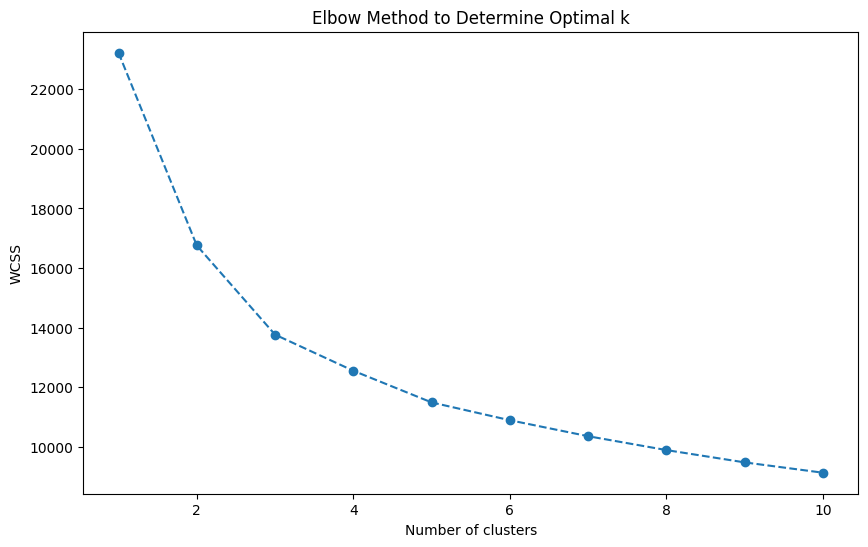

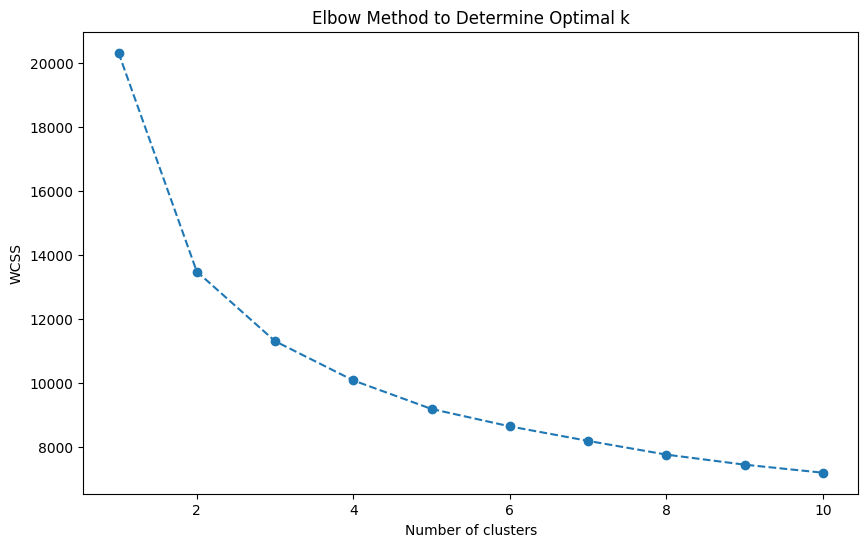

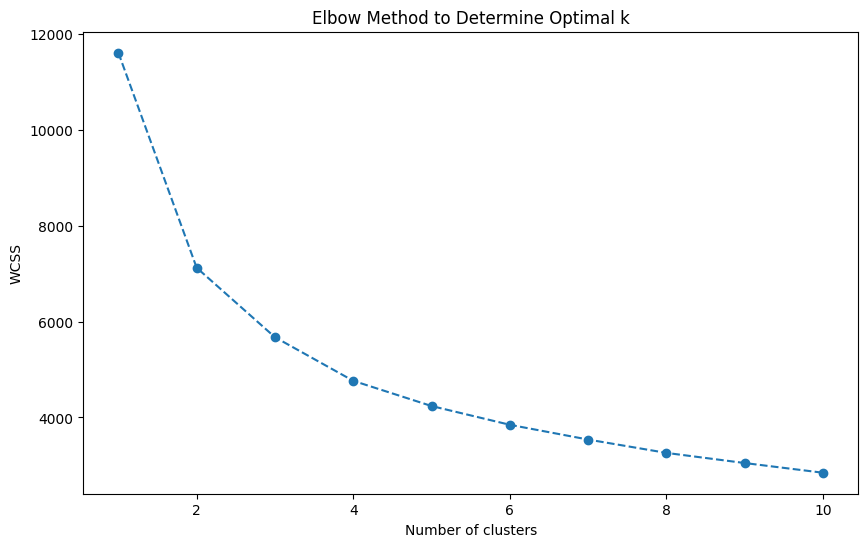

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def determine_optimal_k(data, max_k=10):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    wcss = []  # Within-cluster sum of squares
    for i in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(data_scaled)
        wcss.append(kmeans.inertia_)

    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
    plt.title('Elbow Method to Determine Optimal k')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

# Example usage for the 'Physical' group
determine_optimal_k(data[groups['Physical']], max_k=10)
# Repeat for 'Cognitive' and 'Psychological' groups

determine_optimal_k(data[groups['Cognitive']], max_k=10)

determine_optimal_k(data[groups['Psychological']], max_k=10)

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# Function to perform K-means clustering and add cluster labels to the data
def perform_kmeans_clustering(data, optimal_k):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    kmeans.fit(data_scaled)

    # Adding the cluster labels to the original data
    data['Cluster'] = kmeans.labels_
    return data

# Clustering for each group
# Replace 'optimal_k_physical', etc., with the actual values
physical_clustered = perform_kmeans_clustering(data[groups['Physical']], 3)
cognitive_clustered = perform_kmeans_clustering(data[groups['Cognitive']], 3)
psychological_clustered = perform_kmeans_clustering(data[groups['Psychological']], 3)

# Now, you can analyze the clustered data
physical_clustered = physical_clustered.reset_index(drop=True)
cognitive_clustered = cognitive_clustered.reset_index(drop=True)
psychological_clustered = psychological_clustered.reset_index(drop=True)
#클러스터된 그룹 나눠주기

C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kimte\AppData\Local\Temp\ipykernel_14212\3465392646.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = kmeans.labels_
C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

In [12]:
# Ensure the indices are aligned before merging
#X_train_original = X_train.reset_index(drop=True)

# Merging cluster labels with the original dataset
data['Physical_Cluster'] = physical_clustered['Cluster']
data['Cognitive_Cluster'] = cognitive_clustered['Cluster']
data['Psychological_Cluster'] = psychological_clustered['Cluster']

# Now X_train_original contains the original data along with the cluster labels for each group
data

,BL_age1,sex,RE_height,RE_weight,RE_BMI,BL_calf_cm,BL_waist_cm,sbp_mean_RND,dbp_mean_RND,uparm_cm,...,b_ft4,b_25vtd,b_Free_Testosterone,b_insulin,b_hs_CRP,CKD_EPIcr_equation,BL_CHS_version02_twocat,Physical_Cluster,Cognitive_Cluster,Psychological_Cluster
0,82.26,1,148.0,72.0,32.9,39.0,92.0,119.0,75.0,33.0,...,1.06,11.74,1.21,5.7,1.80,57.98,0,0,2,1
1,70.24,0,165.5,63.3,23.1,33.0,82.0,135.0,75.0,31.0,...,1.10,26.14,10.02,3.1,0.30,90.05,0,1,1,0
2,82.76,1,147.7,47.3,21.7,28.5,78.9,125.0,78.0,26.5,...,1.23,7.52,0.76,3.7,1.00,80.69,0,2,2,0
3,79.51,1,147.7,65.7,30.1,33.0,101.0,135.0,75.0,31.0,...,1.03,13.91,0.84,11.4,2.60,60.81,0,2,1,1
4,72.10,1,152.5,68.5,29.5,33.5,96.5,123.0,86.0,28.0,...,1.49,18.90,1.01,10.6,1.20,87.82,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2898,77.79,1,154.4,54.1,22.7,31.0,84.5,115.0,60.0,26.5,...,1.10,14.36,0.29,8.7,0.37,91.58,0,0,0,0
2899,73.71,0,170.5,67.6,23.3,32.8,86.0,137.0,81.0,31.0,...,1.26,22.81,8.30,4.2,0.24,84.82,0,1,1,0
2900,82.92,1,144.0,54.4,26.2,31.6,94.0,143.0,87.0,28.0,...,1.20,19.75,1.83,8.1,1.00,79.32,0,2,1,1
2901,72.39,0,168.8,65.7,23.1,35.1,88.0,129.0,87.0,32.5,...,1.12,23.15,6.64,4.0,0.45,85.42,0,1,1,0


In [13]:
clustered_data = data[['Physical_Cluster', 'Cognitive_Cluster', 'Psychological_Cluster']]
clustered_data

,Physical_Cluster,Cognitive_Cluster,Psychological_Cluster
0,0,2,1
1,1,1,0
2,2,2,0
3,2,1,1
4,2,1,1
...,...,...,...
2898,0,0,0
2899,1,1,0
2900,2,1,1
2901,1,1,0


In [14]:
# Assuming 'y_train' is your target variable and it's already aligned with 'clustered_data'
#clustered_data['y'] = y_train.reset_index(drop=True)
clustered_data['y'] = data["BL_CHS_version02_twocat"]

# Calculate the count and ratio of each category of 'y' within each cluster
for cluster in ['Physical_Cluster', 'Cognitive_Cluster', 'Psychological_Cluster']:
    cluster_distribution = clustered_data.groupby(cluster)['y'].value_counts(normalize=True).unstack()
    cluster_distribution_percentage = cluster_distribution * 100  # Convert to percentage

    print(f"Distribution in {cluster}:")
    print(cluster_distribution_percentage)
    print("\n")

clustered_data

Distribution in Physical_Cluster:
y                         0          1
Physical_Cluster                      
0                 97.455471   2.544529
1                 97.953964   2.046036
2                 68.421053  31.578947


Distribution in Cognitive_Cluster:
y                          0          1
Cognitive_Cluster                      
0                  92.186326   7.813674
1                  97.983501   2.016499
2                  78.794179  21.205821


Distribution in Psychological_Cluster:
y                              0          1
Psychological_Cluster                      
0                      98.456790   1.543210
1                      89.790210  10.209790
2                      77.112676  22.887324




C:\Users\kimte\AppData\Local\Temp\ipykernel_14212\3216665308.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustered_data['y'] = data["BL_CHS_version02_twocat"]


,Physical_Cluster,Cognitive_Cluster,Psychological_Cluster,y
0,0,2,1,0
1,1,1,0,0
2,2,2,0,0
3,2,1,1,0
4,2,1,1,0
...,...,...,...,...
2898,0,0,0,0
2899,1,1,0,0
2900,2,1,1,0
2901,1,1,0,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Assuming 'clustered_data' contains your features including cluster labels
# and 'y' is your target variable

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(clustered_data.drop('y',axis=1), clustered_data['y'], test_size=0.3, random_state=42)

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

y_probs = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {roc_auc}")

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       800
           1       0.50      0.23      0.31        71

    accuracy                           0.92       871
   macro avg       0.72      0.60      0.63       871
weighted avg       0.90      0.92      0.90       871

ROC AUC Score: 0.8029049295774648


In [16]:
def perform_kmeans_clustering(data, optimal_k):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    kmeans.fit(data_scaled)

    # Adding the cluster labels to the original data
    data['Cluster'] = kmeans.labels_

    # Returning the fitted model along with the clustered data
    return kmeans, data

# Apply clustering to each group
physical_model, physical_clustered = perform_kmeans_clustering(data[groups['Physical']], 3)
cognitive_model, cognitive_clustered = perform_kmeans_clustering(data[groups['Cognitive']], 3)
psychological_model, psychological_clustered = perform_kmeans_clustering(data[groups['Psychological']], 3)

# Function to print the centroids
def print_centroids(kmeans_model, group_name):
    centroids = kmeans_model.cluster_centers_
    print(f"Centroids for {group_name} Clusters:")
    for i, centroid in enumerate(centroids):
        print(f"  Cluster {i}: {centroid}")

# Print centroids for each group
print_centroids(physical_model, "Physical")
print_centroids(cognitive_model, "Cognitive")
print_centroids(psychological_model, "Psychological")

C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kimte\AppData\Local\Temp\ipykernel_14212\3133445738.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = kmeans.labels_
C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Centroids for Physical Clusters:
  Cluster 0: [-0.26580592 -0.62757577 -0.29568987 -0.54689717 -0.30301405  0.31381346
  0.13917777 -0.70833558]
  Cluster 1: [-0.09687773  0.9077636   0.54688409  0.93019073 -0.29257973  0.35240779
  0.3842581   0.92702669]
  Cluster 2: [ 0.77499593 -0.58964586 -0.53153663 -0.81002171  1.27123335 -1.42170673
 -1.11583547 -0.45784876]
Centroids for Cognitive Clusters:
  Cluster 0: [-0.01499898 -0.1493193  -0.15431629 -0.28233913 -0.29535776 -0.06332362
 -0.07765158]
  Cluster 1: [ 0.64572145  0.62005176  0.64873302  0.81609424  0.826227   -0.55597704
  0.70097495]
  Cluster 2: [-1.43451221 -1.00315519 -1.05485659 -1.08224318 -1.06928622  1.44666377
 -1.38699086]
Centroids for Psychological Clusters:
  Cluster 0: [ 0.54965727  0.6529476   0.28673013 -0.50223884]
  Cluster 1: [-0.54360181 -0.96082449  0.46619604 -0.09566693]
  Cluster 2: [-0.88399626 -0.65224829 -1.40793505  1.55577503]


In [17]:
# 각 클러스터 조합별로 노쇠화 비율을 계산합니다.
cluster_combination_fatigue_ratios = {}

# 모든 가능한 클러스터 조합을 순회합니다.
for physical_cluster in [0, 1, 2]:
    for cognitive_cluster in [0, 1, 2]:
        for psychological_cluster in [0, 1, 2]:
            # 현재 클러스터 조합에 해당하는 데이터를 필터링합니다.
            cluster_combination = clustered_data[
                (clustered_data['Physical_Cluster'] == physical_cluster) &
                (clustered_data['Cognitive_Cluster'] == cognitive_cluster) &
                (clustered_data['Psychological_Cluster'] == psychological_cluster)
            ]

            # 노쇠화 발생 비율을 계산합니다.
            fatigue_ratio = cluster_combination['y'].mean() if not cluster_combination.empty else None

            # 결과를 저장합니다.
            cluster_combination_fatigue_ratios[(physical_cluster, cognitive_cluster, psychological_cluster)] = fatigue_ratio

# 가장 높은 노쇠화 비율을 가진 클러스터 조합을 찾습니다.
max_fatigue_combination = max(cluster_combination_fatigue_ratios, key=cluster_combination_fatigue_ratios.get)
max_fatigue_ratio = cluster_combination_fatigue_ratios[max_fatigue_combination]

print(f"The cluster combination with the highest fatigue occurrence is: {max_fatigue_combination} with a ratio of {max_fatigue_ratio}")
cluster_combination_fatigue_ratios

The cluster combination with the highest fatigue occurrence is: (2, 2, 2) with a ratio of 0.5181818181818182


{(0, 0, 0): 0.010869565217391304,
 (0, 0, 1): 0.03125,
 (0, 0, 2): 0.08461538461538462,
 (0, 1, 0): 0.0036101083032490976,
 (0, 1, 1): 0.0,
 (0, 1, 2): 0.02,
 (0, 2, 0): 0.018867924528301886,
 (0, 2, 1): 0.0,
 (0, 2, 2): 0.12307692307692308,
 (1, 0, 0): 0.010666666666666666,
 (1, 0, 1): 0.05063291139240506,
 (1, 0, 2): 0.08333333333333333,
 (1, 1, 0): 0.0020920502092050207,
 (1, 1, 1): 0.028985507246376812,
 (1, 1, 2): 0.1111111111111111,
 (1, 2, 0): 0.02631578947368421,
 (1, 2, 1): 0.1111111111111111,
 (1, 2, 2): 0.0,
 (2, 0, 0): 0.1,
 (2, 0, 1): 0.29591836734693877,
 (2, 0, 2): 0.4444444444444444,
 (2, 1, 0): 0.14814814814814814,
 (2, 1, 1): 0.06451612903225806,
 (2, 1, 2): 0.4375,
 (2, 2, 0): 0.1111111111111111,
 (2, 2, 1): 0.31521739130434784,
 (2, 2, 2): 0.5181818181818182}

In [18]:
#합친 데이터 업로드
data_1 = pd.read_csv("/Users/kimte/Desktop/노인노쇠코호트/merged_kfacs_data.csv")
print(data_1['D4year_frail_1'])

# Replace blank spaces with 0 in 'D4year_frail_1' column
data_1['D4year_frail_1'] = data_1['D4year_frail_1'].replace(' ', 0)

# 필요없는 컬럼 제거
columns_to_remove = ['BL_CHS_version02', 'Polypharmacy', 'comorbidities_No_13', 'No']
data_1 = data_1.drop(columns=columns_to_remove)

# 범주형 변수 인코딩
label_encoder = LabelEncoder()
data_1['b_HBs_Ag'] = label_encoder.fit_transform(data_1['b_HBs_Ag'])
data_1['sex'] = label_encoder.fit_transform(data_1['sex'])
data_1
data_1['D4year_frail_1'] = data_1['D4year_frail_1'].astype(int)

0        
1       0
2       0
3       0
4       0
       ..
2898    0
2899     
2900    0
2901    0
2902    0
Name: D4year_frail_1, Length: 2903, dtype: object


In [19]:
def perform_kmeans_clustering(data, optimal_k):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    kmeans.fit(data_scaled)

    # Adding the cluster labels to the original data
    data['Cluster'] = kmeans.labels_

    # Returning the fitted model along with the clustered data
    return kmeans, data

# Apply clustering to each group
physical_model, physical_clustered = perform_kmeans_clustering(data_1[groups['Physical']], 3)
cognitive_model, cognitive_clustered = perform_kmeans_clustering(data_1[groups['Cognitive']], 3)
psychological_model, psychological_clustered = perform_kmeans_clustering(data_1[groups['Psychological']], 3)

# Function to print the centroids
def print_centroids(kmeans_model, group_name):
    centroids = kmeans_model.cluster_centers_
    print(f"Centroids for {group_name} Clusters:")
    for i, centroid in enumerate(centroids):
        print(f"  Cluster {i}: {centroid}")

# Print centroids for each group
print_centroids(physical_model, "Physical")
print_centroids(cognitive_model, "Cognitive")
print_centroids(psychological_model, "Psychological")

Centroids for Physical Clusters:
  Cluster 0: [-0.26580592 -0.62757577 -0.29568987 -0.54689717 -0.30301405  0.31381346
  0.13917777 -0.70833558]
  Cluster 1: [-0.09687773  0.9077636   0.54688409  0.93019073 -0.29257973  0.35240779
  0.3842581   0.92702669]
  Cluster 2: [ 0.77499593 -0.58964586 -0.53153663 -0.81002171  1.27123335 -1.42170673
 -1.11583547 -0.45784876]
Centroids for Cognitive Clusters:
  Cluster 0: [-0.01499898 -0.1493193  -0.15431629 -0.28233913 -0.29535776 -0.06332362
 -0.07765158]
  Cluster 1: [ 0.64572145  0.62005176  0.64873302  0.81609424  0.826227   -0.55597704
  0.70097495]
  Cluster 2: [-1.43451221 -1.00315519 -1.05485659 -1.08224318 -1.06928622  1.44666377
 -1.38699086]
Centroids for Psychological Clusters:
  Cluster 0: [ 0.54965727  0.6529476   0.28673013 -0.50223884]
  Cluster 1: [-0.54360181 -0.96082449  0.46619604 -0.09566693]
  Cluster 2: [-0.88399626 -0.65224829 -1.40793505  1.55577503]


C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\kimte\AppData\Local\Temp\ipykernel_14212\1337024118.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = kmeans.labels_
C:\Users\kimte\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [20]:
def calculate_fatigue_ratios_assumed(data, y_column):
    fatigue_ratios = {}
    for physical_cluster in [0, 1, 2]:
        for cognitive_cluster in [0, 1, 2]:
            for psychological_cluster in [0, 1, 2]:
                cluster_combination = data[
                    (data['Physical_Cluster'] == physical_cluster) &
                    (data['Cognitive_Cluster'] == cognitive_cluster) &
                    (data['Psychological_Cluster'] == psychological_cluster)
                ]

                fatigue_ratio = cluster_combination[y_column].mean() if not cluster_combination.empty else None
                fatigue_ratios[(physical_cluster, cognitive_cluster, psychological_cluster)] = fatigue_ratio

    return fatigue_ratios

In [21]:
# Merging cluster labels with the original dataset
data_1['Physical_Cluster'] = physical_clustered['Cluster']
data_1['Cognitive_Cluster'] = cognitive_clustered['Cluster']
data_1['Psychological_Cluster'] = psychological_clustered['Cluster']

In [22]:
data_1

,D4year_mortality,D4year_frail_1,BL_comorbidity,BL_age1,sex,RE_height,RE_weight,RE_BMI,BL_calf_cm,BL_waist_cm,...,b_ft4,b_25vtd,b_Free_Testosterone,b_insulin,b_hs_CRP,CKD_EPIcr_equation,BL_CHS_version02_twocat,Physical_Cluster,Cognitive_Cluster,Psychological_Cluster
0,0,0,1,82.26,1,148.0,72.0,32.9,39.0,92.0,...,1.06,11.74,1.21,5.7,1.80,57.98,0,0,2,1
1,0,0,0,70.24,0,165.5,63.3,23.1,33.0,82.0,...,1.10,26.14,10.02,3.1,0.30,90.05,0,1,1,0
2,0,0,1,82.76,1,147.7,47.3,21.7,28.5,78.9,...,1.23,7.52,0.76,3.7,1.00,80.69,0,2,2,0
3,0,0,1,79.51,1,147.7,65.7,30.1,33.0,101.0,...,1.03,13.91,0.84,11.4,2.60,60.81,0,2,1,1
4,0,0,1,72.10,1,152.5,68.5,29.5,33.5,96.5,...,1.49,18.90,1.01,10.6,1.20,87.82,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2898,0,0,0,77.79,1,154.4,54.1,22.7,31.0,84.5,...,1.10,14.36,0.29,8.7,0.37,91.58,0,0,0,0
2899,0,0,0,73.71,0,170.5,67.6,23.3,32.8,86.0,...,1.26,22.81,8.30,4.2,0.24,84.82,0,1,1,0
2900,0,0,1,82.92,1,144.0,54.4,26.2,31.6,94.0,...,1.20,19.75,1.83,8.1,1.00,79.32,0,2,1,1
2901,0,0,0,72.39,0,168.8,65.7,23.1,35.1,88.0,...,1.12,23.15,6.64,4.0,0.45,85.42,0,1,1,0


In [23]:
calculate_fatigue_ratios_assumed(data_1,'BL_CHS_version02_twocat')
BL_CHS_version02_twocat_ratios_desc = dict(sorted(calculate_fatigue_ratios_assumed(data_1,'BL_CHS_version02_twocat').items(), key=lambda item: item[1], reverse=True))
BL_CHS_version02_twocat_ratios_desc

{(2, 2, 2): 0.5181818181818182,
 (2, 0, 2): 0.4444444444444444,
 (2, 1, 2): 0.4375,
 (2, 2, 1): 0.31521739130434784,
 (2, 0, 1): 0.29591836734693877,
 (2, 1, 0): 0.14814814814814814,
 (0, 2, 2): 0.12307692307692308,
 (1, 1, 2): 0.1111111111111111,
 (1, 2, 1): 0.1111111111111111,
 (2, 2, 0): 0.1111111111111111,
 (2, 0, 0): 0.1,
 (0, 0, 2): 0.08461538461538462,
 (1, 0, 2): 0.08333333333333333,
 (2, 1, 1): 0.06451612903225806,
 (1, 0, 1): 0.05063291139240506,
 (0, 0, 1): 0.03125,
 (1, 1, 1): 0.028985507246376812,
 (1, 2, 0): 0.02631578947368421,
 (0, 1, 2): 0.02,
 (0, 2, 0): 0.018867924528301886,
 (0, 0, 0): 0.010869565217391304,
 (1, 0, 0): 0.010666666666666666,
 (0, 1, 0): 0.0036101083032490976,
 (1, 1, 0): 0.0020920502092050207,
 (0, 1, 1): 0.0,
 (0, 2, 1): 0.0,
 (1, 2, 2): 0.0}

In [24]:
calculate_fatigue_ratios_assumed(data_1,'D4year_mortality')
D4year_mortality_ratios_desc = dict(sorted(calculate_fatigue_ratios_assumed(data_1,'D4year_mortality').items(), key=lambda item: item[1], reverse=True))
D4year_mortality_ratios_desc

{(2, 2, 0): 0.16666666666666666,
 (2, 1, 1): 0.12903225806451613,
 (1, 2, 2): 0.125,
 (1, 2, 1): 0.1111111111111111,
 (2, 1, 0): 0.1111111111111111,
 (0, 2, 2): 0.1076923076923077,
 (1, 2, 0): 0.10526315789473684,
 (2, 2, 1): 0.09782608695652174,
 (1, 0, 2): 0.08333333333333333,
 (2, 2, 2): 0.08181818181818182,
 (1, 1, 1): 0.07246376811594203,
 (1, 0, 1): 0.06329113924050633,
 (2, 1, 2): 0.0625,
 (2, 0, 1): 0.061224489795918366,
 (1, 0, 0): 0.05333333333333334,
 (0, 2, 1): 0.03278688524590164,
 (0, 0, 2): 0.03076923076923077,
 (1, 1, 0): 0.027196652719665274,
 (0, 0, 0): 0.021739130434782608,
 (0, 0, 1): 0.01875,
 (0, 1, 1): 0.018691588785046728,
 (0, 1, 0): 0.01444043321299639,
 (2, 0, 2): 0.012345679012345678,
 (0, 1, 2): 0.0,
 (0, 2, 0): 0.0,
 (1, 1, 2): 0.0,
 (2, 0, 0): 0.0}

In [25]:
calculate_fatigue_ratios_assumed(data_1,'D4year_frail_1')
D4year_frail_1_ratios_desc = dict(sorted(calculate_fatigue_ratios_assumed(data_1,'D4year_frail_1').items(), key=lambda item: item[1], reverse=True))
D4year_frail_1_ratios_desc

{(1, 2, 1): 0.2222222222222222,
 (2, 2, 2): 0.19090909090909092,
 (2, 1, 0): 0.18518518518518517,
 (2, 0, 1): 0.1836734693877551,
 (2, 0, 0): 0.18333333333333332,
 (0, 2, 1): 0.16393442622950818,
 (2, 2, 1): 0.16304347826086957,
 (2, 0, 2): 0.16049382716049382,
 (2, 1, 1): 0.12903225806451613,
 (1, 0, 1): 0.12658227848101267,
 (2, 1, 2): 0.125,
 (1, 0, 2): 0.09722222222222222,
 (2, 2, 0): 0.08333333333333333,
 (1, 2, 0): 0.07894736842105263,
 (1, 1, 1): 0.07246376811594203,
 (0, 0, 1): 0.06875,
 (0, 2, 2): 0.06153846153846154,
 (0, 1, 1): 0.056074766355140186,
 (1, 1, 2): 0.05555555555555555,
 (0, 0, 2): 0.05384615384615385,
 (0, 1, 2): 0.04,
 (1, 0, 0): 0.034666666666666665,
 (0, 0, 0): 0.03260869565217391,
 (1, 1, 0): 0.02092050209205021,
 (0, 2, 0): 0.018867924528301886,
 (0, 1, 0): 0.01444043321299639,
 (1, 2, 2): 0.0}

In [26]:
calculate_fatigue_ratios_assumed(data_1,'BL_comorbidity')
BL_comorbidity_ratios_desc = dict(sorted(calculate_fatigue_ratios_assumed(data_1,'BL_comorbidity').items(), key=lambda item: item[1], reverse=True))
BL_comorbidity_ratios_desc

{(2, 2, 1): 0.7608695652173914,
 (2, 1, 1): 0.6451612903225806,
 (1, 2, 1): 0.6111111111111112,
 (2, 0, 1): 0.6020408163265306,
 (2, 2, 2): 0.5727272727272728,
 (2, 1, 2): 0.5625,
 (1, 0, 1): 0.5316455696202531,
 (2, 0, 2): 0.5308641975308642,
 (1, 0, 2): 0.5277777777777778,
 (0, 0, 1): 0.50625,
 (0, 1, 1): 0.5046728971962616,
 (0, 2, 1): 0.47540983606557374,
 (2, 0, 0): 0.4666666666666667,
 (1, 1, 1): 0.4492753623188406,
 (0, 2, 2): 0.4461538461538462,
 (0, 0, 2): 0.4230769230769231,
 (2, 2, 0): 0.4166666666666667,
 (0, 1, 2): 0.4,
 (0, 2, 0): 0.39622641509433965,
 (1, 0, 0): 0.344,
 (2, 1, 0): 0.3333333333333333,
 (0, 0, 0): 0.32608695652173914,
 (1, 2, 0): 0.3157894736842105,
 (1, 1, 0): 0.3138075313807531,
 (0, 1, 0): 0.30685920577617326,
 (1, 1, 2): 0.3055555555555556,
 (1, 2, 2): 0.25}

In [27]:
pip install imbalanced-learn

In [28]:
#추가분석 해보기
from imblearn.over_sampling import SMOTE

# 데이터 준비
X = data_1.drop('BL_CHS_version02_twocat', axis=1)  # 특성
y = data_1['BL_CHS_version02_twocat']  # 타겟 변수

# SMOTE 적용
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 새로운 분포 확인
new_distribution = pd.Series(y_resampled).value_counts(normalize=True) * 100
print(new_distribution)

BL_CHS_version02_twocat
0    50.0
1    50.0
Name: proportion, dtype: float64


In [49]:
# 필요없는 컬럼 제거
columns_to_remove = ['D4year_mortality','D4year_frail_1','BL_comorbidity',"Physical_Cluster","Cognitive_Cluster","Psychological_Cluster"]
X_resampled = X_resampled.drop(columns=columns_to_remove)

In [54]:
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# 랜덤 포레스트 모델 초기화
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

np.int = np.int32
np.float = np.float64
np.bool = np.bool_

In [63]:
# Boruta 초기화 및 실행
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42,max_iter=9)
boruta_selector.fit(X_train.values, y_train.values)

# 피처 중요도 평가
selected_features = X_resampled.columns[boruta_selector.support_]

# 선택된 피처 출력
print("Selected Features: ", selected_features)

feature_ranks = boruta_selector.ranking_
ranking_df = pd.DataFrame({'Feature': X_resampled.columns, 'Rank': feature_ranks})
ranking_df.sort_values(by='Rank', inplace=True)

print(ranking_df.head(50))

Selected Features:  Index(['BL_age1', 'sex', 'RE_height', 'RE_weight', 'RE_BMI', 'BL_calf_cm',
       'BL_waist_cm', 'sbp_mean_RND', 'dbp_mean_RND', 'uparm_cm',
       'Maximum_grip_strength_both', 'tug_test', 'SPPB_total_score',
       'UGS_recoding_data', 'BL_heart_rate', 'BL_pr_inter', 'BL_rr_inter',
       'BL_qrs', 'BL_qt', 'BL_Qtc', 're_BL_arm_fat_kg', 're_BL_arm_lean_kg',
       're_BL_arm_total_kg', 're_BL_leg_fat_kg', 're_BL_leg_lean_kg',
       're_BL_leg_total_kg', 're_BL_ASM_kg', 're_BL_trunk_fat_kg',
       're_BL_trunk_lean_kg', 're_BL_trunk_total_kg', 're_BL_total_fat_kg',
       're_BL_total_lean_kg', 're_BL_total_total_kg', 're_BL_FMI_kg',
       're_BL_MMI_kg', 're_BL_MMI_FMI_kg', 're_BL_WWI', 'RE_MMSE_KC_30score',
       'BL_recall_score', 'BL_recog_score', 'BL_memory_score', 'BL_span_score',
       'BL_span_for_score', 'BL_span_back_score', 're_BL_tmt_recode_final',
       'BL_fab_score', 'Estimated_utility_eq5d_index', 'AGG_PHYS', 'AGG_MENT',
       'BL_sgdsk_score

In [64]:
print(ranking_df)

                Feature  Rank
0               BL_age1     1
69    b_hdl_cholesterol     1
68       b_triglyceride     1
67  b_total_cholesterol     1
66    b_creatine_kinase     1
..                  ...   ...
26         re_BL_ASM_kg     1
25   re_BL_leg_total_kg     1
35     re_BL_MMI_FMI_kg     1
97   CKD_EPIcr_equation     1
88             b_HBs_Ag     2

[98 rows x 2 columns]


In [38]:
# X_resampled와 y_resampled를 합치기
# 여기서는 y_resampled를 DataFrame으로 변환하고, 그 후에 X_resampled와 같은 인덱스를 가지도록 조정합니다.
y_resampled_df = pd.DataFrame(y_resampled, columns=['BL_CHS_version02_twocat'])
resampled_data = pd.concat([X_resampled, y_resampled_df], axis=1)

# 새로운 DataFrame 확인
resampled_data

61

In [73]:
resampled_data = X_resampled.copy()
resampled_data['target'] = y_resampled

# CSV 파일로 저장합니다. 'resampled_data.csv'는 원하는 파일 이름으로 변경하세요.
output_file_path = 'C:/Users/kimte/resampled_data.csv'
resampled_data.to_csv(output_file_path, index=False)

# 저장된 파일의 경로를 출력합니다.
print(f"Resampled data saved to {output_file_path}")

Resampled data saved to C:/Users/kimte/resampled_data.csv


In [75]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# 타겟 변수 'target'을 기반으로 피처(X)와 타겟(y) 변수 분리
X_resampled = resampled_data.drop('target', axis=1)
y_resampled = resampled_data['target']

# 랜덤 포레스트 분류기 초기화
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

# Boruta 알고리즘 초기화
boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42)

# Boruta 알고리즘 실행
boruta.fit(X_resampled.values, y_resampled.values)

# 선택된 피처 확인
selected_features = X_resampled.columns[boruta.support_].tolist()
print("Selected Features:", selected_features)


# 각 피처의 랭킹
feature_ranks = boruta.ranking_

# 피처와 그들의 랭킹을 출력
ranked_features = [(feature, rank) for feature, rank in zip(X_resampled.columns, feature_ranks)]
ranked_features_sorted = sorted(ranked_features, key=lambda x: x[1])

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	98
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	97
Tentative: 	1
Rejected: 	0
Iteration: 	9 / 100
Confirmed: 	97
Tentative: 	1
Rejected: 	0
Iteration: 	10 / 100
Confirmed: 	97
Tentative: 	1
Rejected: 	0
Iteration: 	11 / 100
Confirmed: 	97
Tentative: 	0
Rejected: 	1


BorutaPy finished running.

Iteration: 	12 / 100
Confirmed: 	97
Tentative: 	0
Rejected: 	1
Selected Features: ['BL_age1', 'sex', 'RE_height', 'RE_weight', 'RE_BMI', 'BL_calf_cm', 'BL_waist_cm', 'sbp_mean_RND', 'dbp_mean_RND', 'uparm_cm', 'Maximum_grip_strength_both', 'tug_test', 'SPPB_total_score', 'UGS_recoding_

In [76]:
ranked_features_sorted

[('BL_age1', 1),
 ('sex', 1),
 ('RE_height', 1),
 ('RE_weight', 1),
 ('RE_BMI', 1),
 ('BL_calf_cm', 1),
 ('BL_waist_cm', 1),
 ('sbp_mean_RND', 1),
 ('dbp_mean_RND', 1),
 ('uparm_cm', 1),
 ('Maximum_grip_strength_both', 1),
 ('tug_test', 1),
 ('SPPB_total_score', 1),
 ('UGS_recoding_data', 1),
 ('BL_heart_rate', 1),
 ('BL_pr_inter', 1),
 ('BL_rr_inter', 1),
 ('BL_qrs', 1),
 ('BL_qt', 1),
 ('BL_Qtc', 1),
 ('re_BL_arm_fat_kg', 1),
 ('re_BL_arm_lean_kg', 1),
 ('re_BL_arm_total_kg', 1),
 ('re_BL_leg_fat_kg', 1),
 ('re_BL_leg_lean_kg', 1),
 ('re_BL_leg_total_kg', 1),
 ('re_BL_ASM_kg', 1),
 ('re_BL_trunk_fat_kg', 1),
 ('re_BL_trunk_lean_kg', 1),
 ('re_BL_trunk_total_kg', 1),
 ('re_BL_total_fat_kg', 1),
 ('re_BL_total_lean_kg', 1),
 ('re_BL_total_total_kg', 1),
 ('re_BL_FMI_kg', 1),
 ('re_BL_MMI_kg', 1),
 ('re_BL_MMI_FMI_kg', 1),
 ('re_BL_WWI', 1),
 ('RE_MMSE_KC_30score', 1),
 ('BL_recall_score', 1),
 ('BL_recog_score', 1),
 ('BL_memory_score', 1),
 ('BL_span_score', 1),
 ('BL_span_for_score',